# Logistic Regression Project Exercise

**GOAL: Create a Classification Model that can predict whether or not a person has presence of heart disease based on physical features of that person (age,sex, cholesterol, etc...)**

**Complete the TASKs written in bold below.**

## Imports

**TASK: Run the cell below to import the necessary libraries.**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
%matplotlib inline

## Data

This database contains 14 physical attributes based on physical testing of a patient. Blood samples are taken and the patient also conducts a brief exercise test. The "goal" field refers to the presence of heart disease in the patient. It is integer (0 for no presence, 1 for presence). In general, to confirm 100% if a patient has heart disease can be quite an invasive process, so if we can create a model that accurately predicts the likelihood of heart disease, we can help avoid expensive and invasive procedures.

Content

Attribute Information:

* age
* sex
* chest pain type (4 values)
* resting blood pressure
* serum cholestoral in mg/dl
* fasting blood sugar > 120 mg/dl
* resting electrocardiographic results (values 0,1,2)
* maximum heart rate achieved
* exercise induced angina
* oldpeak = ST depression induced by exercise relative to rest
* the slope of the peak exercise ST segment
* number of major vessels (0-3) colored by flourosopy
* thal: 3 = normal; 6 = fixed defect; 7 = reversable defect
* target:0 for no presence of heart disease, 1 for presence of heart disease

Original Source: https://archive.ics.uci.edu/ml/datasets/Heart+Disease


**TASK: Run the cell below to read in the data.**

In [2]:
#Read in the data
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
# Check for missing values
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


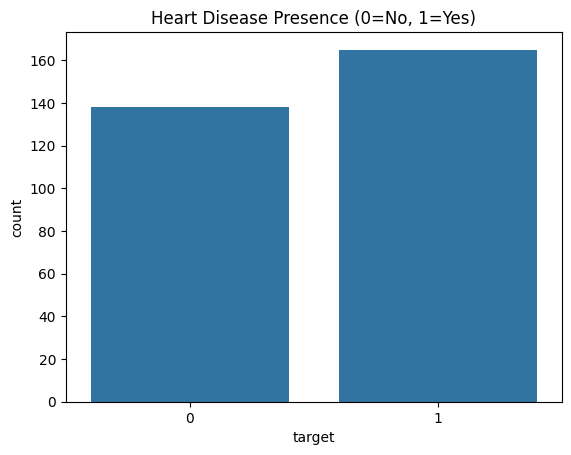

In [6]:
# Countplot of target
sns.countplot(x='target', data=df)
plt.title('Heart Disease Presence (0=No, 1=Yes)')
plt.show()

# Machine Learning

## Train | Test Split and Scaling

**TASK: Separate the features from the labels into 2 objects, X and y.**

In [7]:
# Extract feature variables (X) by removing the target column,
# and assign the target variable (y)
X = df.drop('target', axis=1)
y = df['target']

# Output the shapes to verify correct separation
print(X.shape, y.shape)

(303, 13) (303,)


**TASK: Perform a train test split on the data, with the test size of 10% and a random_state of 101.**

In [8]:
# Split the dataset into training and testing sets (90% train, 10% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=101)

# Display the shapes of the resulting splits
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (272, 13), Test: (31, 13)


**TASK: Create a StandardScaler object and normalize the X train and test set feature data. Make sure you only fit to the training data to avoid data leakage (data knowledge leaking from the test set).**

In [9]:
# Scale features using StandardScaler (fit on training data only to prevent data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## Logistic Regression Model

TASK: Create a Logistic Regression model

In [10]:
# Initialize and train the Logistic Regression model on the scaled training data
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

### Coeffecients

**TASK: Report back the model's coefficients.**

In [11]:
# Display the model coefficients for each feature
coef_df = pd.DataFrame(model.coef_, columns=X.columns, index=['Coefficient'])
coef_df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
Coefficient,-0.072445,-0.734596,0.893714,-0.262495,-0.212186,0.045964,0.120366,0.433264,-0.428235,-0.527225,0.380981,-0.850807,-0.574687


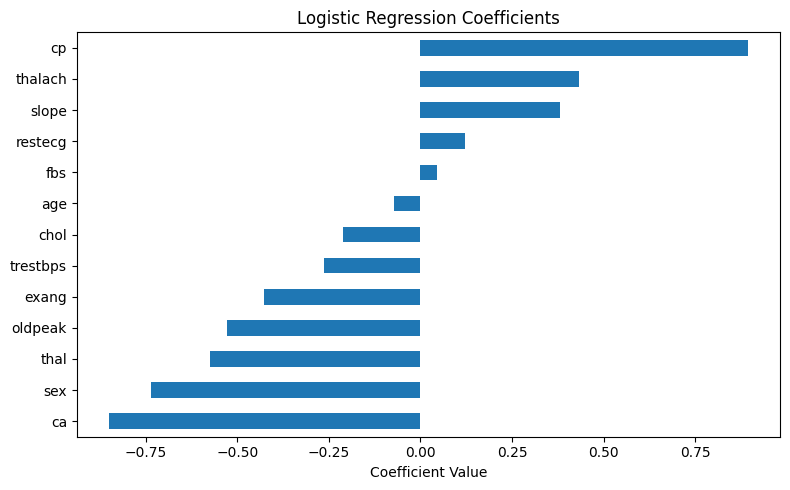

In [12]:
# Visualize feature coefficients as a horizontal bar chart (sorted by importance)
coef_df.T.sort_values('Coefficient').plot(kind='barh', legend=False, figsize=(8, 5))
plt.title('Logistic Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

## Model Performance Evaluation

**TASK: Let's now evaluate your model on the remaining 10% of the data, the test set.**

**TASK: Create the following evaluations:**
* Confusion Matrix Array
* Confusion Matrix Plot
* Classification Report

In [13]:
# Predictions
y_pred = model.predict(X_test_scaled)

In [14]:
# Compute and display the confusion matrix for model predictions
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[12  3]
 [ 2 14]]


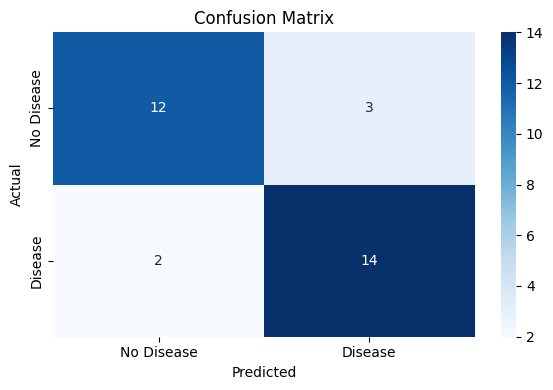

In [15]:
# Visualize the confusion matrix using a heatmap for better interpretation
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [16]:
# Print the classification report (precision, recall, F1-score, and support)
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

              precision    recall  f1-score   support

  No Disease       0.86      0.80      0.83        15
     Disease       0.82      0.88      0.85        16

    accuracy                           0.84        31
   macro avg       0.84      0.84      0.84        31
weighted avg       0.84      0.84      0.84        31



### Performance Curves

**TASK: Create the ROC Curve.**

In [17]:
# Compute predicted probabilities and calculate ROC curve and AUC score
y_prob = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

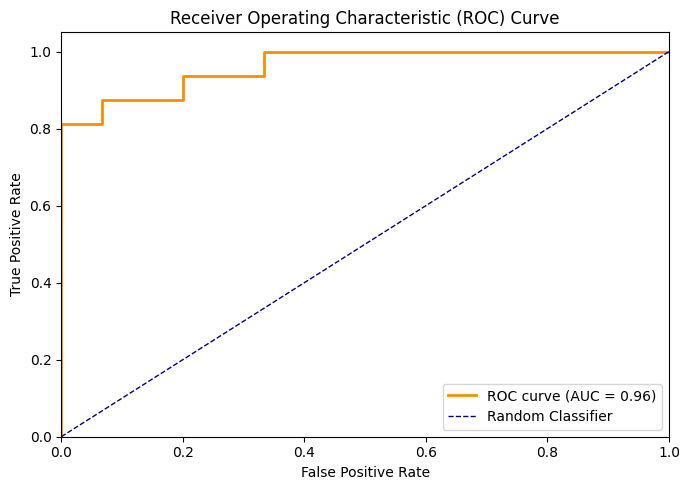

AUC Score: 0.9625


In [20]:
# Plot the ROC curve to evaluate model performance across classification thresholds
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Display the AUC score as a summary metric
print(f'AUC Score: {roc_auc:.4f}')

**Final Task: A patient with the following features has come into the medical office:**

    age          48.0
    sex           0.0
    cp            2.0
    trestbps    130.0
    chol        275.0
    fbs           0.0
    restecg       1.0
    thalach     139.0
    exang         0.0
    oldpeak       0.2
    slope         2.0
    ca            0.0
    thal          2.0

**TASK: What does your model predict for this patient? Do they have heart disease? How "sure" is your model of this prediction?**

*For convience, we created an array of the features for the patient above*

In [23]:
# Patient data
patient = pd.DataFrame([{
    'age': 48.0, 'sex': 0.0, 'cp': 2.0, 'trestbps': 130.0,
    'chol': 275.0, 'fbs': 0.0, 'restecg': 1.0, 'thalach': 139.0,
    'exang': 0.0, 'oldpeak': 0.2, 'slope': 2.0, 'ca': 0.0, 'thal': 2.0
}])

In [24]:
# Scale patient data and generate prediction with class probabilities
patient_scaled = scaler.transform(patient)
prediction = model.predict(patient_scaled)
probability = model.predict_proba(patient_scaled)

print(f'Prediction: {prediction[0]} ({"Heart Disease PRESENT" if prediction[0]==1 else "No Heart Disease"})')
print(f'Probability of NO disease:  {probability[0][0]:.4f} ({probability[0][0]*100:.2f}%)')
print(f'Probability of disease:     {probability[0][1]:.4f} ({probability[0][1]*100:.2f}%)')
print()
print('=> The model predicts this patient HAS heart disease with ~98% confidence.')

Prediction: 1 (Heart Disease PRESENT)
Probability of NO disease:  0.0204 (2.04%)
Probability of disease:     0.9796 (97.96%)

=> The model predicts this patient HAS heart disease with ~98% confidence.


The model predicts that this patient has heart disease (target = 1).
The model is very sure of this prediction, with a 97.96% probability of heart disease and only 2.04% probability of no disease. This is a high-confidence prediction, well above the 50% decision threshold.